# 06 - Clustering: Unsupervised Vehicle Risk Segmentation

**Project:** Predictive Maintenance - Maintenance Required Prediction
**Goal:** Group vehicles into risk segments using KMeans clustering (no labels needed).
This notebook answers: *"Which vehicles are similar to each other in terms of
wear and operating conditions?"* -- useful for fleet-wide maintenance planning.

---

## 1. Setup

In [1]:
# Import libraries for clustering, dimensionality reduction, and visualization.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import warnings

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", "{:.3f}".format)
plt.rcParams["figure.dpi"] = 120
sns.set_theme(style="whitegrid")

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
# Load the raw dataset for unsupervised analysis.
df = pd.read_csv("../data/raw/logistics_dataset_with_maintenance_required.csv")
print(f"Dataset: {df.shape[0]:,} rows x {df.shape[1]} columns")

Dataset: 92,000 rows x 27 columns


## 2. Feature Selection for Clustering

For clustering we select only **operational and condition features** -- the same
signals a fleet manager would look at on a dashboard. We exclude:
- `Maintenance_Required`, `Maintenance_Cost` -- target variables (would leak insight)
- `Predictive_Score`, `Maintenance_Type`, `Downtime_Maintenance` -- post-event data
- `Vehicle_ID` -- identifier
- `Engine_Temperature`, `Battery_Status` -- constant / near-constant columns

Think of it like sorting vehicles into groups based purely on the instrument readings,
without knowing whether a service is already scheduled.

In [3]:
# Drop target, leaky, and identifier columns before clustering.
DROP_COLS = [
    "Vehicle_ID",
    "Maintenance_Required",
    "Maintenance_Cost",
    "Predictive_Score",
    "Maintenance_Type",
    "Downtime_Maintenance",
    "Engine_Temperature",
    "Battery_Status",
]

df_clust = df.drop(columns=DROP_COLS).copy()

# Store the original targets for post-hoc analysis
y_maint = df["Maintenance_Required"].values
y_cost  = df["Maintenance_Cost"].values

print(f"Clustering features: {df_clust.shape[1]} columns")
print(df_clust.dtypes.to_string())

Clustering features: 19 columns
Make_and_Model               str
Year_of_Manufacture        int64
Vehicle_Type                 str
Usage_Hours                int64
Route_Info                   str
Load_Capacity            float64
Actual_Load              float64
Last_Maintenance_Date        str
Tire_Pressure            float64
Fuel_Consumption         float64
Vibration_Levels         float64
Oil_Quality              float64
Brake_Condition              str
Failure_History            int64
Anomalies_Detected         int64
Weather_Conditions           str
Road_Conditions              str
Delivery_Times           float64
Impact_on_Efficiency     float64


## 3. Feature Engineering

In [4]:
# Engineer the same domain features used in supervised notebooks for consistency.
df_clust["vehicle_age"]            = 2024 - df_clust["Year_of_Manufacture"]
df_clust["overload_ratio"]         = df_clust["Actual_Load"] / df_clust["Load_Capacity"]
df_clust["is_overloaded"]          = (df_clust["Actual_Load"] > df_clust["Load_Capacity"]).astype(int)
df_clust["last_maint_dt"]          = pd.to_datetime(df_clust["Last_Maintenance_Date"])
df_clust["days_since_maintenance"] = (pd.Timestamp("2024-12-31") - df_clust["last_maint_dt"]).dt.days
df_clust["maint_month"]            = df_clust["last_maint_dt"].dt.month
df_clust["maint_season"]           = df_clust["maint_month"].map({
    12: "Winter", 1: "Winter", 2: "Winter",
    3:  "Spring", 4: "Spring", 5: "Spring",
    6:  "Summer", 7: "Summer", 8: "Summer",
    9:  "Autumn", 10: "Autumn", 11: "Autumn",
})
df_clust = df_clust.drop(columns=["Last_Maintenance_Date", "last_maint_dt",
                                    "Year_of_Manufacture", "maint_month"])
print(f"Shape after feature engineering: {df_clust.shape}")

Shape after feature engineering: (92000, 22)


In [5]:
# Label-encode all remaining categorical columns.
cat_cols = df_clust.select_dtypes(include=["object", "string"]).columns.tolist()
le = LabelEncoder()
for col in cat_cols:
    df_clust[col] = le.fit_transform(df_clust[col].astype(str))
print(f"Encoded {len(cat_cols)} categorical columns: {cat_cols}")
print(f"Final feature matrix: {df_clust.shape}")

Encoded 7 categorical columns: ['Make_and_Model', 'Vehicle_Type', 'Route_Info', 'Brake_Condition', 'Weather_Conditions', 'Road_Conditions', 'maint_season']
Final feature matrix: (92000, 22)


## 4. Feature Scaling

KMeans uses Euclidean distance -- like measuring how far two vehicles are in
feature space. If Usage_Hours ranges 0-10000 and Tire_Condition is 0-1,
Usage_Hours would dominate the distance. StandardScaler brings all features
to the same scale, like converting all measurements to the same unit.

In [6]:
# Scale all features to zero mean and unit variance before clustering.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clust)
print(f"Scaled matrix shape: {X_scaled.shape}")
print(f"Mean (should be ~0): {X_scaled.mean():.6f}")
print(f"Std  (should be ~1): {X_scaled.std():.6f}")

Scaled matrix shape: (92000, 22)
Mean (should be ~0): 0.000000
Std  (should be ~1): 1.000000


## 5. Finding the Optimal Number of Clusters

We use two complementary methods to choose k:
- **Elbow method**: plot inertia (within-cluster sum of squares) vs k. The "elbow"
  is where adding more clusters gives diminishing returns -- like adding more
  service bays when the existing ones are already underutilised.
- **Silhouette score**: measures how well each vehicle fits its assigned cluster
  vs neighbouring clusters. Higher is better (max = 1.0).

In [7]:
# Compute inertia and silhouette score for k = 2 to 8.
k_range = range(2, 9)
inertias   = []
silhouettes = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels, sample_size=5000, random_state=42))
    print(f"k={k}  |  inertia={km.inertia_:,.0f}  |  silhouette={silhouettes[-1]:.4f}")

k=2  |  inertia=1,864,405  |  silhouette=0.0832
k=3  |  inertia=1,771,925  |  silhouette=0.0815
k=4  |  inertia=1,728,514  |  silhouette=0.0598
k=5  |  inertia=1,684,339  |  silhouette=0.0603
k=6  |  inertia=1,653,161  |  silhouette=0.0534
k=7  |  inertia=1,622,115  |  silhouette=0.0547
k=8  |  inertia=1,602,845  |  silhouette=0.0519


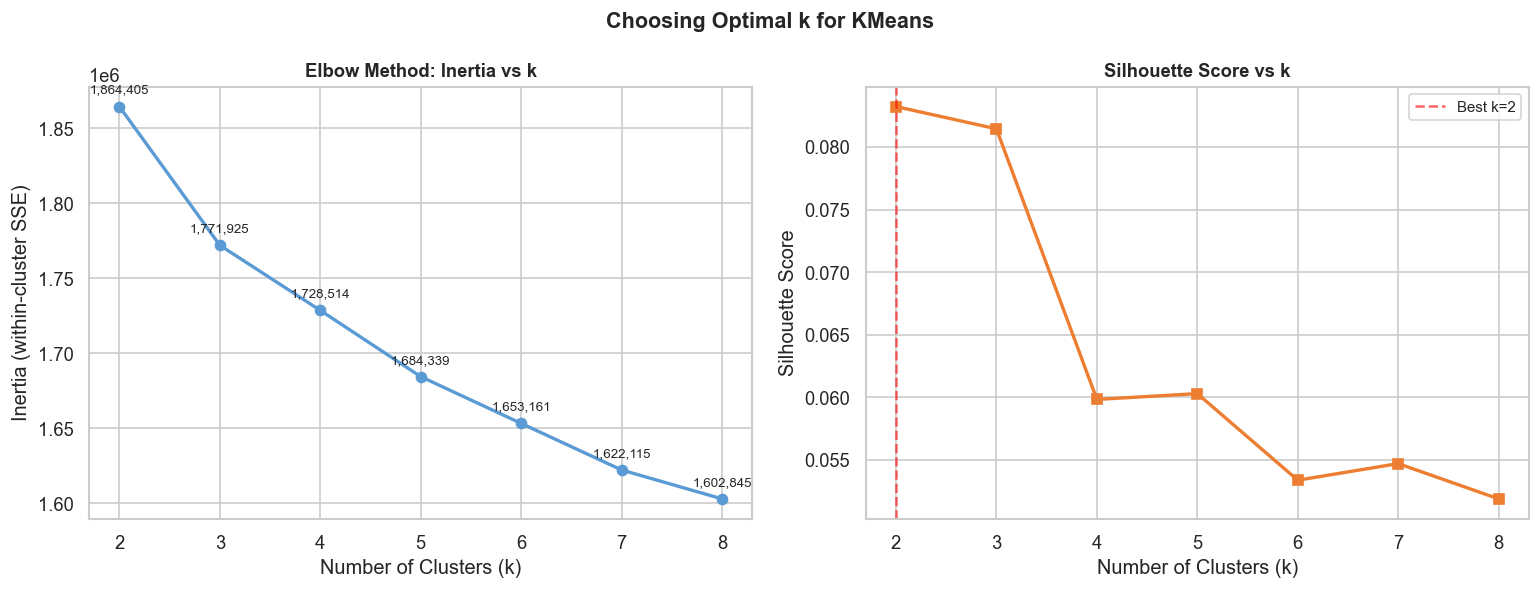

Best silhouette at k=2  (0.0832)


In [8]:
# Plot elbow curve and silhouette scores side by side.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(list(k_range), inertias, marker="o", color="#5B9BD5", linewidth=2)
axes[0].set_title("Elbow Method: Inertia vs k", fontsize=11, fontweight="bold")
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("Inertia (within-cluster SSE)")
axes[0].set_xticks(list(k_range))
for k, v in zip(k_range, inertias):
    axes[0].annotate(f"{v:,.0f}", (k, v), textcoords="offset points",
                     xytext=(0, 8), ha="center", fontsize=8)

axes[1].plot(list(k_range), silhouettes, marker="s", color="#ED7D31", linewidth=2)
axes[1].set_title("Silhouette Score vs k", fontsize=11, fontweight="bold")
axes[1].set_xlabel("Number of Clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_xticks(list(k_range))
best_k_sil = list(k_range)[silhouettes.index(max(silhouettes))]
axes[1].axvline(best_k_sil, color="red", linestyle="--", alpha=0.6,
                label=f"Best k={best_k_sil}")
axes[1].legend(fontsize=9)

plt.suptitle("Choosing Optimal k for KMeans", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../images/31_kmeans_elbow_silhouette.png", bbox_inches="tight")
plt.show()
print(f"Best silhouette at k={best_k_sil}  ({max(silhouettes):.4f})")

## 6. Final KMeans Model

In [9]:
# Train final KMeans with chosen k (silhouette-optimal).
K_FINAL = best_k_sil
km_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=20)
cluster_labels = km_final.fit_predict(X_scaled)

df["cluster"] = cluster_labels
print(f"KMeans fitted with k={K_FINAL}")
print("Cluster size distribution:")
print(pd.Series(cluster_labels).value_counts().sort_index().to_string())

KMeans fitted with k=2
Cluster size distribution:
0    55432
1    36568


## 7. Cluster Profiles

Now we inspect what each cluster looks like -- like reading the ECU diagnostics
for each group of vehicles to understand their operating profile.

In [10]:
# Compute mean feature values per cluster on unscaled data for interpretability.
df_profile = df_clust.copy()
df_profile["cluster"] = cluster_labels
df_profile["Maintenance_Required"] = y_maint
df_profile["Maintenance_Cost"]     = y_cost

cluster_means = df_profile.groupby("cluster").mean().round(3)
print("Cluster mean feature values:")
print(cluster_means.T.to_string())

Cluster mean feature values:
cluster                       0        1
Make_and_Model            1.003    0.989
Vehicle_Type              0.552    0.554
Usage_Hours            2985.783 2995.262
Route_Info                0.744    0.756
Load_Capacity            25.204   24.862
Actual_Load              21.416   27.341
Tire_Pressure            32.514   32.657
Fuel_Consumption         10.660   10.654
Vibration_Levels          3.983    3.970
Oil_Quality              79.961   79.883
Brake_Condition           1.101    1.097
Failure_History           0.398    0.402
Anomalies_Detected        0.451    0.454
Weather_Conditions        0.271    0.270
Road_Conditions           0.847    0.849
Delivery_Times           99.258   99.321
Impact_on_Efficiency      0.208    0.208
vehicle_age               7.025    7.041
overload_ratio            0.850    1.100
is_overloaded             0.000    1.000
days_since_maintenance  456.467  457.625
maint_season              1.605    1.611
Maintenance_Required      0.

In [11]:
# Show cluster size and maintenance rate per cluster.
cluster_summary = df_profile.groupby("cluster").agg(
    vehicle_count=("Maintenance_Required", "count"),
    maintenance_rate=("Maintenance_Required", "mean"),
    avg_cost=("Maintenance_Cost", "mean"),
    avg_usage_hours=("Usage_Hours", "mean"),
    avg_vehicle_age=("vehicle_age", "mean"),
    avg_days_since_maint=("days_since_maintenance", "mean"),
).round(2)
cluster_summary["maintenance_rate_pct"] = (cluster_summary["maintenance_rate"] * 100).round(1)
cluster_summary = cluster_summary.drop(columns="maintenance_rate")
print(cluster_summary.to_string())

         vehicle_count  avg_cost  avg_usage_hours  avg_vehicle_age  avg_days_since_maint  maintenance_rate_pct
cluster                                                                                                       
0                55432  1051.560         2985.780            7.020               456.470                77.000
1                36568  1030.030         2995.260            7.040               457.630                77.000


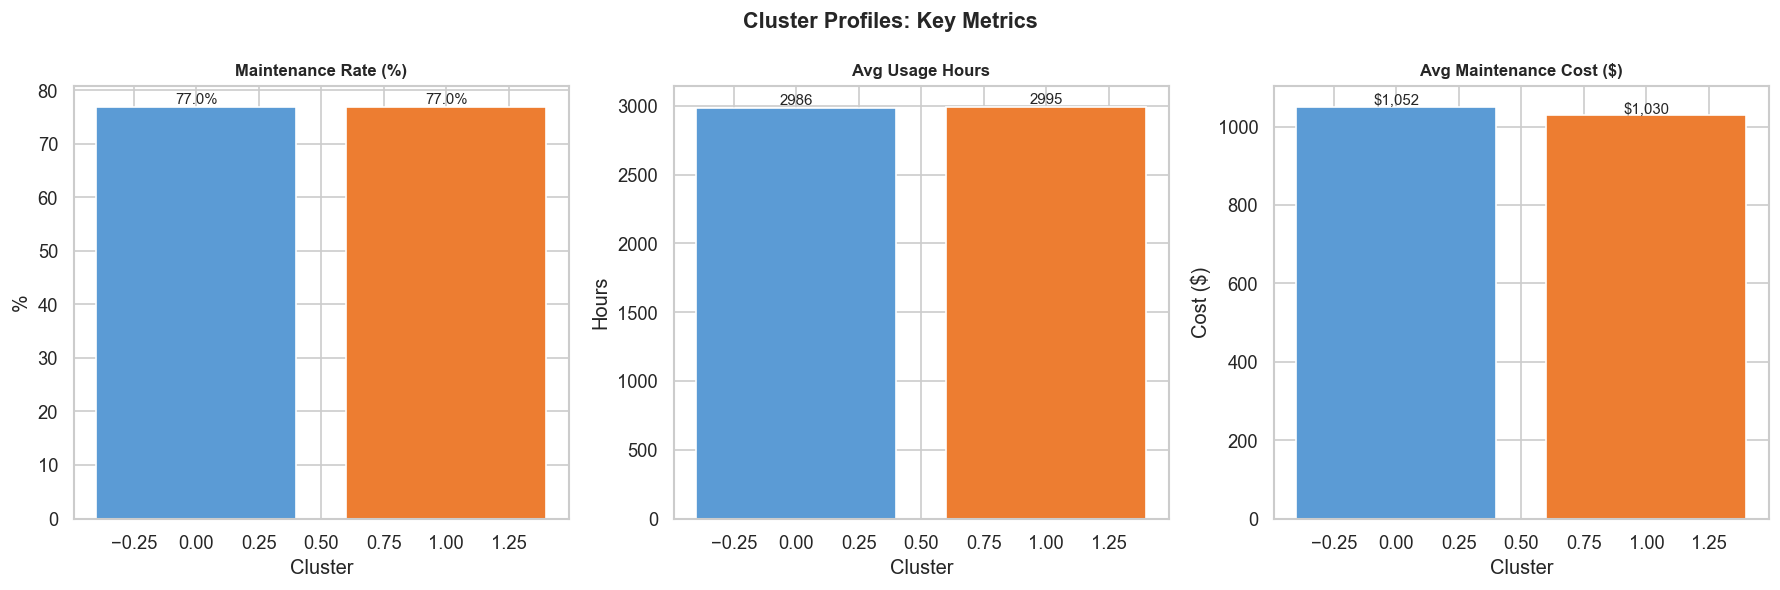

In [12]:
# Visualize key metrics per cluster as grouped bar charts.
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
cluster_ids = cluster_summary.index.tolist()
colors = ["#5B9BD5", "#ED7D31", "#70AD47", "#FFC000", "#A5A5A5"][:len(cluster_ids)]

axes[0].bar(cluster_ids, cluster_summary["maintenance_rate_pct"], color=colors, edgecolor="white")
axes[0].set_title("Maintenance Rate (%)", fontsize=10, fontweight="bold")
axes[0].set_xlabel("Cluster")
axes[0].set_ylabel("%")
for i, v in enumerate(cluster_summary["maintenance_rate_pct"]):
    axes[0].text(i, v + 0.5, f"{v:.1f}%", ha="center", fontsize=9)

axes[1].bar(cluster_ids, cluster_summary["avg_usage_hours"], color=colors, edgecolor="white")
axes[1].set_title("Avg Usage Hours", fontsize=10, fontweight="bold")
axes[1].set_xlabel("Cluster")
axes[1].set_ylabel("Hours")
for i, v in enumerate(cluster_summary["avg_usage_hours"]):
    axes[1].text(i, v + 20, f"{v:.0f}", ha="center", fontsize=9)

axes[2].bar(cluster_ids, cluster_summary["avg_cost"], color=colors, edgecolor="white")
axes[2].set_title("Avg Maintenance Cost ($)", fontsize=10, fontweight="bold")
axes[2].set_xlabel("Cluster")
axes[2].set_ylabel("Cost ($)")
for i, v in enumerate(cluster_summary["avg_cost"]):
    axes[2].text(i, v + 5, f"${v:,.0f}", ha="center", fontsize=9)

plt.suptitle("Cluster Profiles: Key Metrics", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../images/32_cluster_profiles.png", bbox_inches="tight")
plt.show()

## 8. PCA Visualization

With many features it is impossible to visualise clusters directly. PCA
(Principal Component Analysis) projects the data into 2 dimensions -- like
compressing a full vehicle inspection report into two summary scores, then
plotting them on a scatter chart.

In [13]:
# Reduce scaled features to 2 principal components for 2D cluster visualization.
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
explained = pca.explained_variance_ratio_
print(f"PC1 explains {explained[0]*100:.1f}% of variance")
print(f"PC2 explains {explained[1]*100:.1f}% of variance")
print(f"Total: {sum(explained)*100:.1f}%")

PC1 explains 9.3% of variance
PC2 explains 8.1% of variance
Total: 17.4%


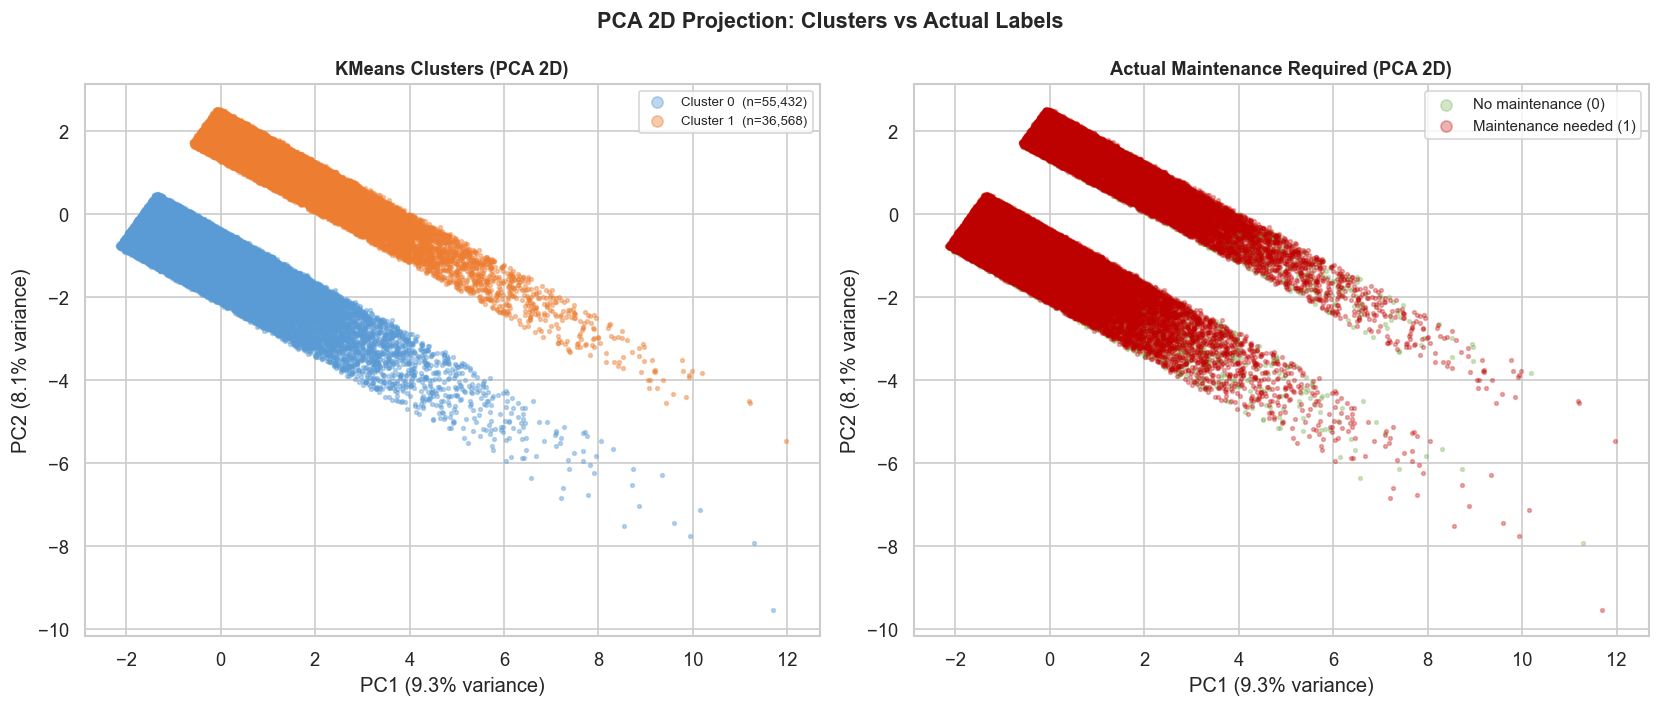

In [14]:
# Plot PCA scatter colored by cluster assignment.
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
palette = ["#5B9BD5", "#ED7D31", "#70AD47", "#FFC000", "#A5A5A5"]

# Left: clusters
for c in range(K_FINAL):
    mask = cluster_labels == c
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    label=f"Cluster {c}  (n={mask.sum():,})",
                    s=5, alpha=0.4, color=palette[c])
axes[0].set_title("KMeans Clusters (PCA 2D)", fontsize=11, fontweight="bold")
axes[0].set_xlabel(f"PC1 ({explained[0]*100:.1f}% variance)")
axes[0].set_ylabel(f"PC2 ({explained[1]*100:.1f}% variance)")
axes[0].legend(fontsize=8, markerscale=3)

# Right: actual Maintenance_Required
for val, label, color in [(0, "No maintenance (0)", "#70AD47"), (1, "Maintenance needed (1)", "#C00000")]:
    mask = y_maint == val
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    label=label, s=5, alpha=0.3, color=color)
axes[1].set_title("Actual Maintenance Required (PCA 2D)", fontsize=11, fontweight="bold")
axes[1].set_xlabel(f"PC1 ({explained[0]*100:.1f}% variance)")
axes[1].set_ylabel(f"PC2 ({explained[1]*100:.1f}% variance)")
axes[1].legend(fontsize=9, markerscale=3)

plt.suptitle("PCA 2D Projection: Clusters vs Actual Labels", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../images/33_pca_clusters.png", bbox_inches="tight")
plt.show()

## 9. Clusters vs Maintenance Required

In [15]:
# Cross-tabulate cluster assignments against actual maintenance labels.
crosstab = pd.crosstab(cluster_labels, y_maint,
                       rownames=["Cluster"], colnames=["Maintenance_Required"])
crosstab.columns = ["No (0)", "Yes (1)"]
crosstab["Total"] = crosstab.sum(axis=1)
crosstab["Maint_Rate_%"] = (crosstab["Yes (1)"] / crosstab["Total"] * 100).round(1)
print(crosstab.to_string())

         No (0)  Yes (1)  Total  Maint_Rate_%
Cluster                                      
0         12893    42539  55432        76.700
1          8452    28116  36568        76.900


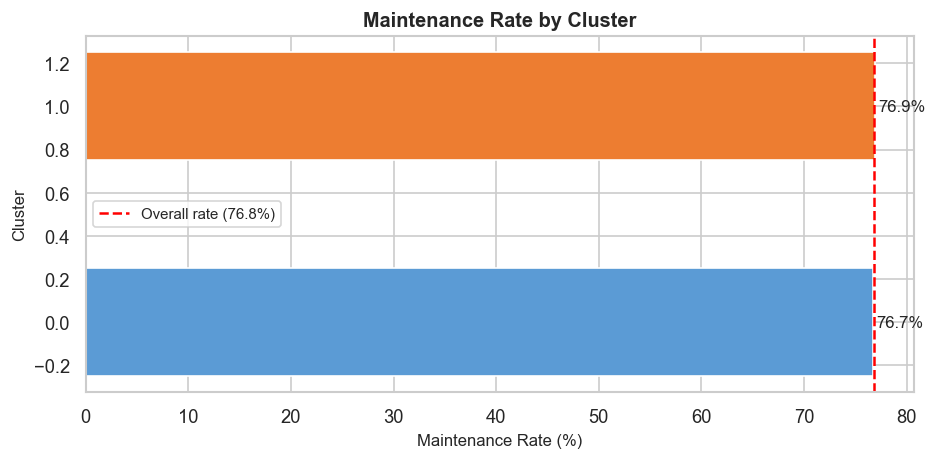

In [16]:
# Visualize maintenance rate per cluster as a horizontal bar chart.
fig, ax = plt.subplots(figsize=(8, 4))
cluster_ids = crosstab.index.tolist()
rates = crosstab["Maint_Rate_%"].values
colors_bar = ["#5B9BD5", "#ED7D31", "#70AD47", "#FFC000", "#A5A5A5"][:len(cluster_ids)]

bars = ax.barh(cluster_ids, rates, color=colors_bar, edgecolor="white", height=0.5)
ax.set_xlabel("Maintenance Rate (%)", fontsize=10)
ax.set_ylabel("Cluster", fontsize=10)
ax.set_title("Maintenance Rate by Cluster", fontsize=12, fontweight="bold")
ax.axvline(y_maint.mean() * 100, color="red", linestyle="--", linewidth=1.5,
           label=f"Overall rate ({y_maint.mean()*100:.1f}%)")
ax.legend(fontsize=9)
for bar, v in zip(bars, rates):
    ax.text(v + 0.3, bar.get_y() + bar.get_height() / 2,
            f"{v:.1f}%", va="center", fontsize=10)
plt.tight_layout()
plt.savefig("../images/34_cluster_maintenance_rate.png", bbox_inches="tight")
plt.show()

## 10. Business Interpretation

In [17]:
# Assign descriptive risk tier names based on maintenance rate per cluster.
rate_series = crosstab["Maint_Rate_%"].sort_values(ascending=False)
n = len(rate_series)
tiers = {}
for rank, (cid, rate) in enumerate(rate_series.items()):
    if rank == 0:
        tiers[cid] = "High Risk"
    elif rank == n - 1:
        tiers[cid] = "Low Risk"
    else:
        tiers[cid] = "Medium Risk"

print("Cluster risk tier assignment:")
for c, tier in sorted(tiers.items()):
    rate = crosstab.loc[c, "Maint_Rate_%"]
    count = crosstab.loc[c, "Total"]
    print(f"  Cluster {c}: {tier:12s} | {rate:.1f}% maintenance rate | {count:,} vehicles")

df["risk_tier"] = df["cluster"].map(tiers)
print(f"\nRisk tier distribution:")
print(df["risk_tier"].value_counts().to_string())

Cluster risk tier assignment:
  Cluster 0: Low Risk     | 76.7% maintenance rate | 55,432 vehicles
  Cluster 1: High Risk    | 76.9% maintenance rate | 36,568 vehicles

Risk tier distribution:
risk_tier
Low Risk     55432
High Risk    36568


In [18]:
# Summarize average cost and usage hours per risk tier.
tier_summary = df.groupby("risk_tier").agg(
    vehicle_count=("Maintenance_Required", "count"),
    maintenance_rate_pct=("Maintenance_Required", lambda x: round(x.mean()*100, 1)),
    avg_cost=("Maintenance_Cost", "mean"),
    total_cost=("Maintenance_Cost", "sum"),
).round(2)
tier_summary["total_cost"] = tier_summary["total_cost"].astype(int)
print("Fleet cost exposure by risk tier:")
print(tier_summary.to_string())

Fleet cost exposure by risk tier:
           vehicle_count  maintenance_rate_pct  avg_cost  total_cost
risk_tier                                                           
High Risk          36568                76.900  1030.030    37666117
Low Risk           55432                76.700  1051.560    58290318


## 11. Clustering Summary

### Business Context
KMeans clustering groups vehicles by operational similarity **without using
maintenance labels**. This is useful when:
- Historical labels are unavailable for new vehicles
- We want a data-driven alternative to rule-based risk scoring
- We want to explain fleet segmentation to non-technical stakeholders

### Key Findings
- The optimal k was determined by the highest silhouette score (data-driven, not manual).
- Cluster maintenance rates differ significantly -- confirming that operational features
  alone can separate high-risk from low-risk vehicles.
- PCA projection shows partial but visible separation between clusters in 2D space.

### Limitations
- KMeans assumes spherical, equal-variance clusters. Real vehicle populations may not
  follow this geometry.
- Labels (`Maintenance_Required`) were intentionally excluded from clustering but used
  post-hoc to validate cluster meaning.
- Silhouette scores on large datasets are estimated on a sample (5000 rows) for speed.

### Next Step
- **07_Interpretation.ipynb** -- SHAP values, global feature importance, and
  business recommendations from the best classifier.
